In [13]:
from pathlib import Path
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

def plot_screening(dataframe: pd.DataFrame, 
                   task:str, 
                   saving_filename: str | Path,
                   additional_info: str):
    for C in ["odd", "even"]:
        if C == "odd":
            caps = [f'CAP{c}'  for c in range(9) if c%2 != 0]
        elif C == "even":
            caps = [f'CAP{c}'  for c in range(9) if c%2 == 0]
        petit_pd = dataframe.groupby(['subject','session','ts_CAPS','n_features']).mean('pearson_r').reset_index()
        selected_caps = petit_pd[petit_pd['ts_CAPS'].isin(caps)]
        figure = plt.figure(figsize=(10,10))
        sns.lineplot(x="n_features", 
                    y="pearson_r",
                    hue="ts_CAPS",
                    data=petit_pd,
                    palette="Paired",
                    errorbar=('ci', 68),
                    #alpha = 1,
                    hue_order=[c  if c in caps else '' for c in dataframe['ts_CAPS'].unique()]
                    )
        if task == 'rest':
            t = "Resting State"
        else:
            t = task.capitalize()
        plt.title(f"Pearson's R for {C} CAPs as a Function of the Number of Features for {t}")
        plt.ylabel('Pearson R')
        plt.xlabel('Number of Features')

        plt.ylim(-0.15,0.6)
        plt.tight_layout()
        plt.savefig(f"/home/slouviot/01_projects/eeg_brain_state_prediction/figures/chang_data/{saving_filename}_{C}_task-{task}_{additional_info}.png")

/tmp/ipykernel_3687470/2689384499.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  group_pd = pd.concat([group_pd, df.reset_index()])


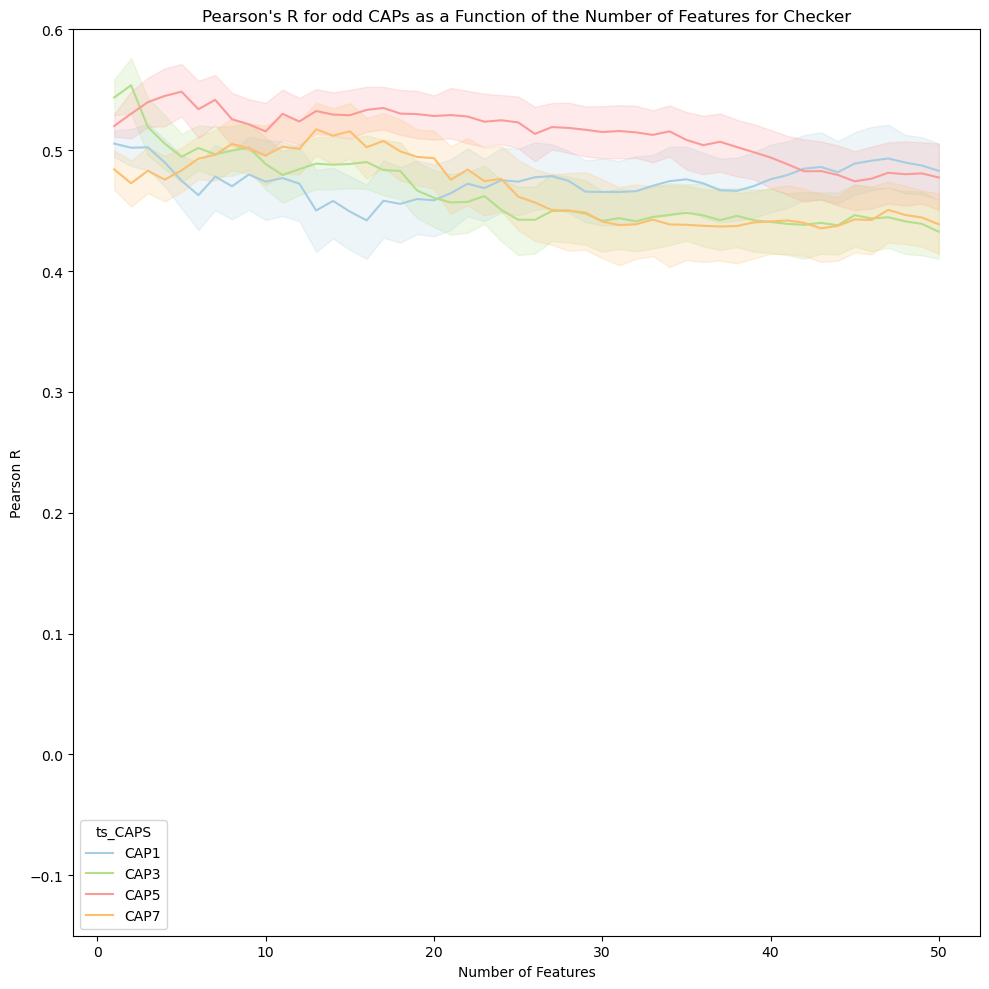

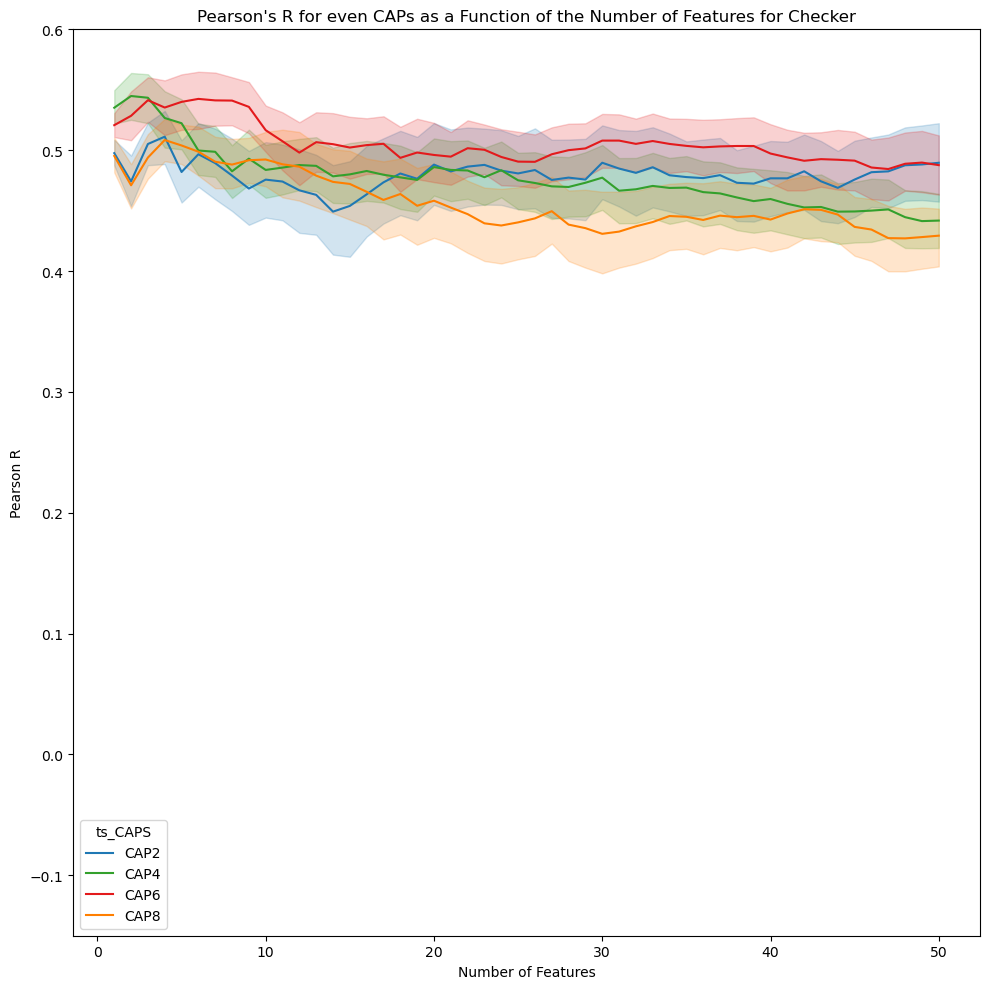

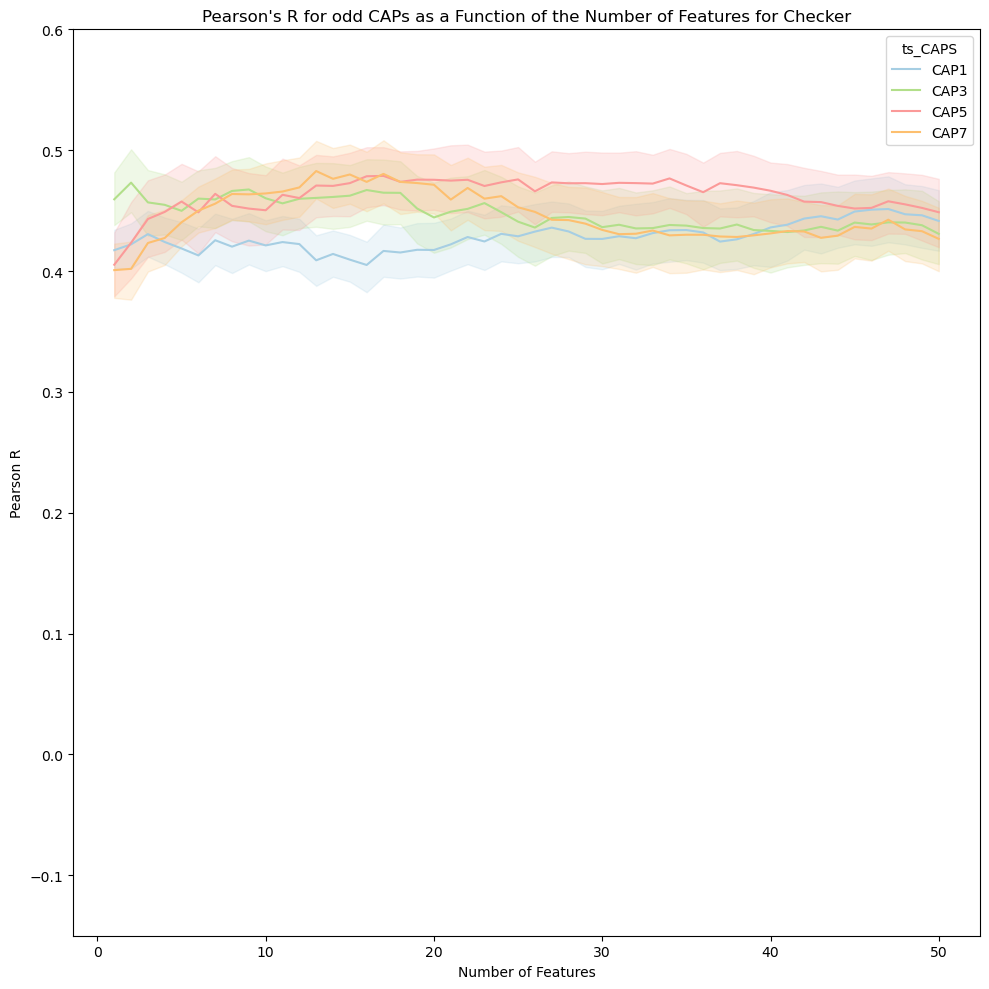

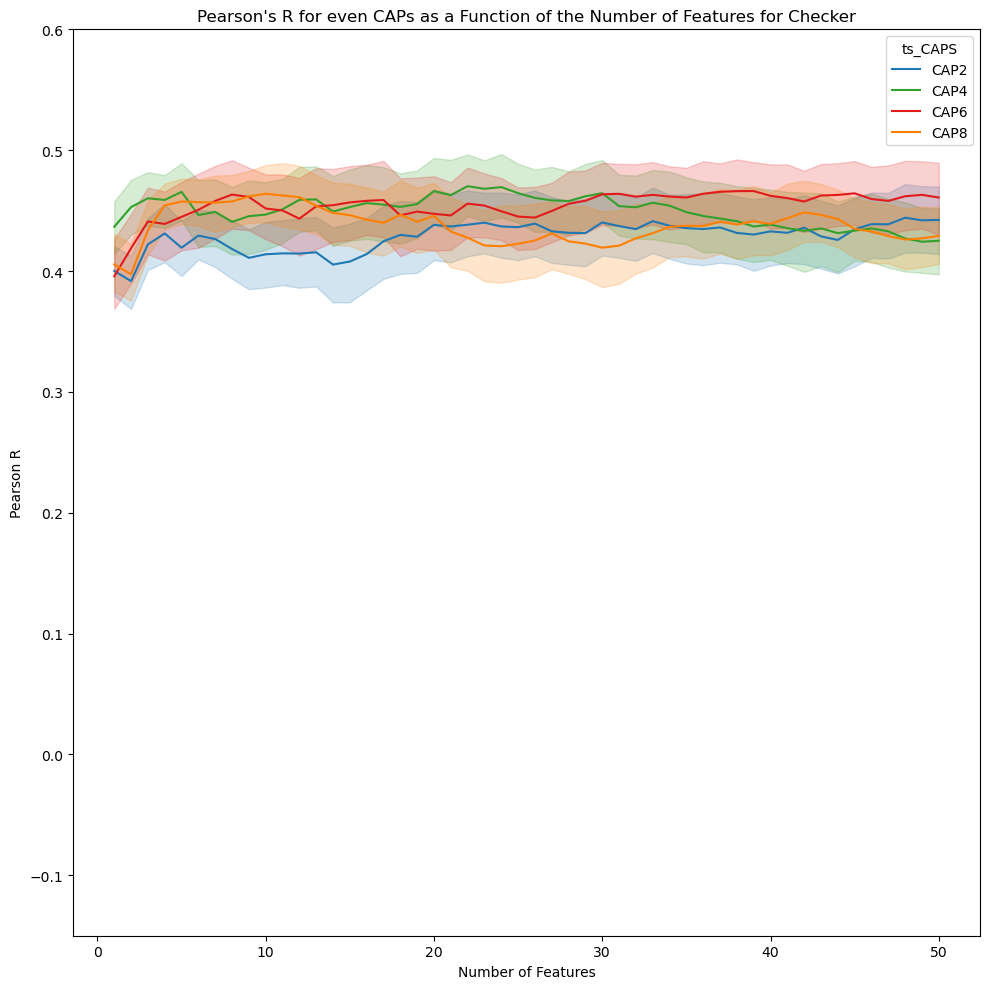

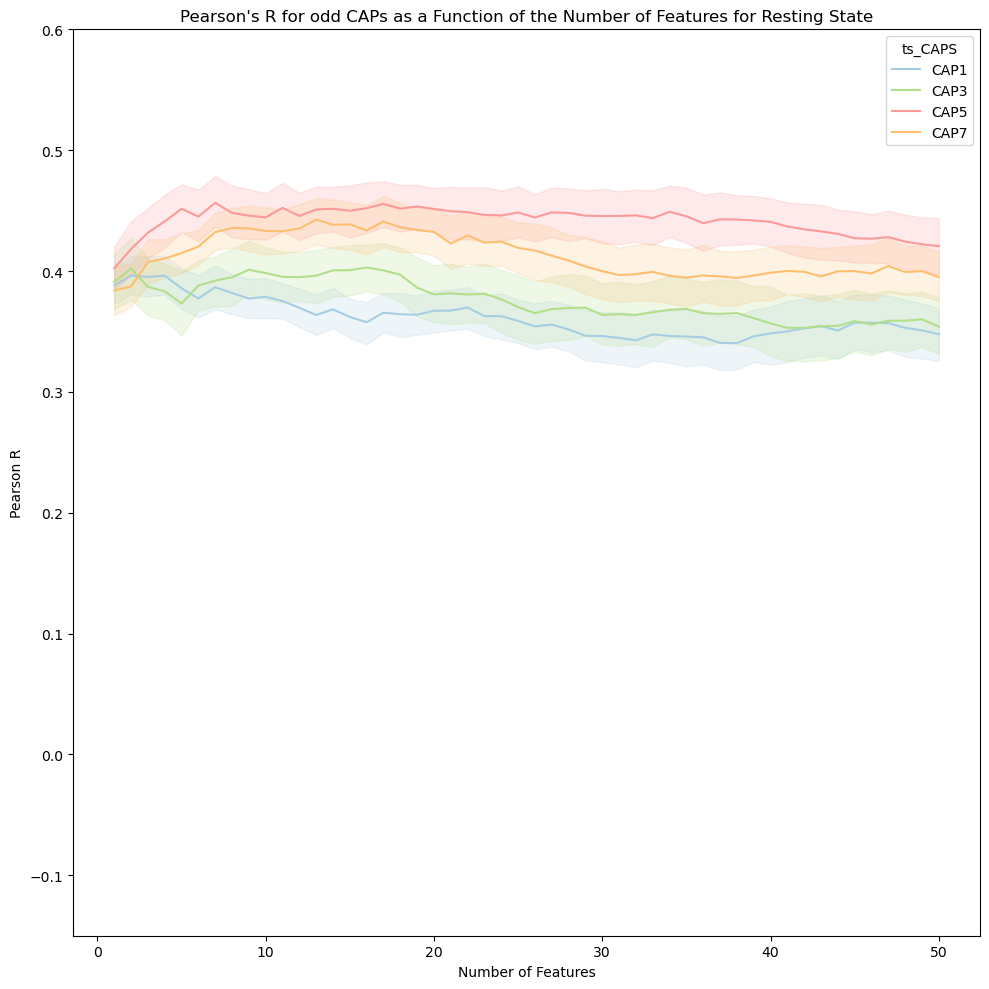

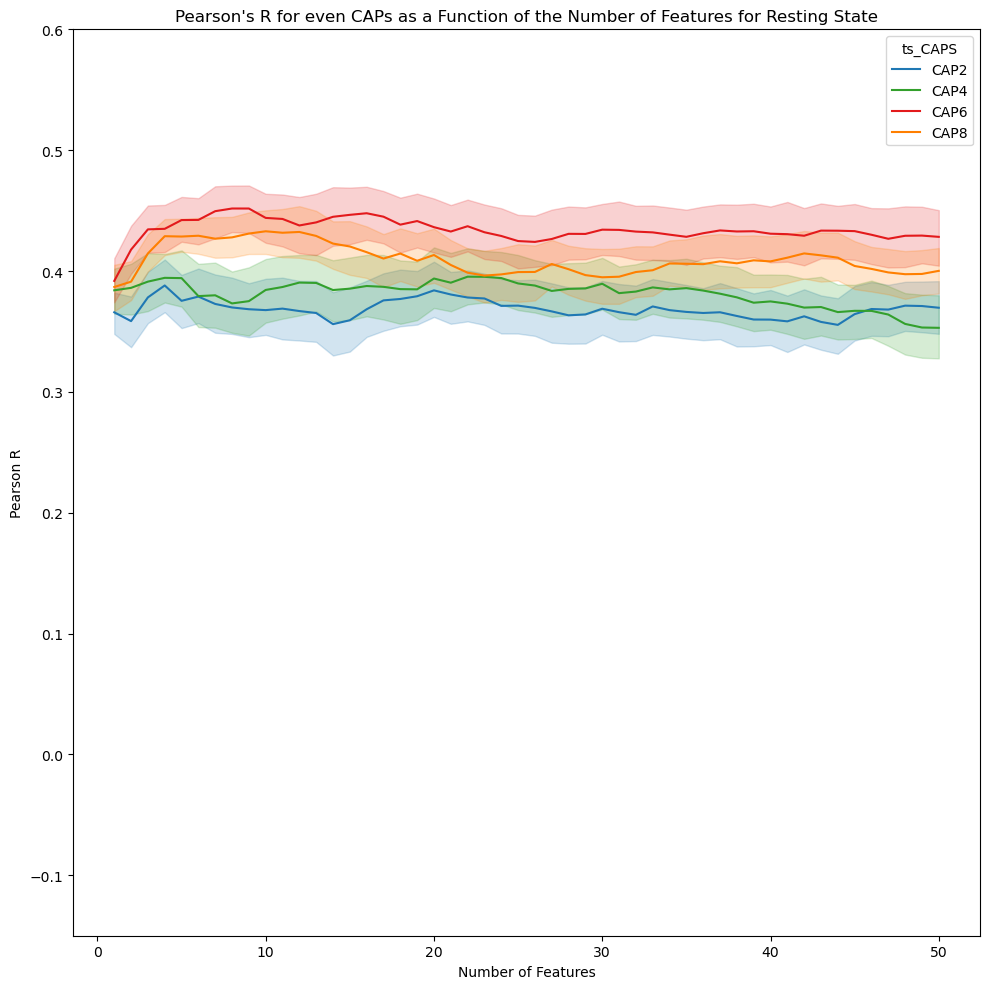

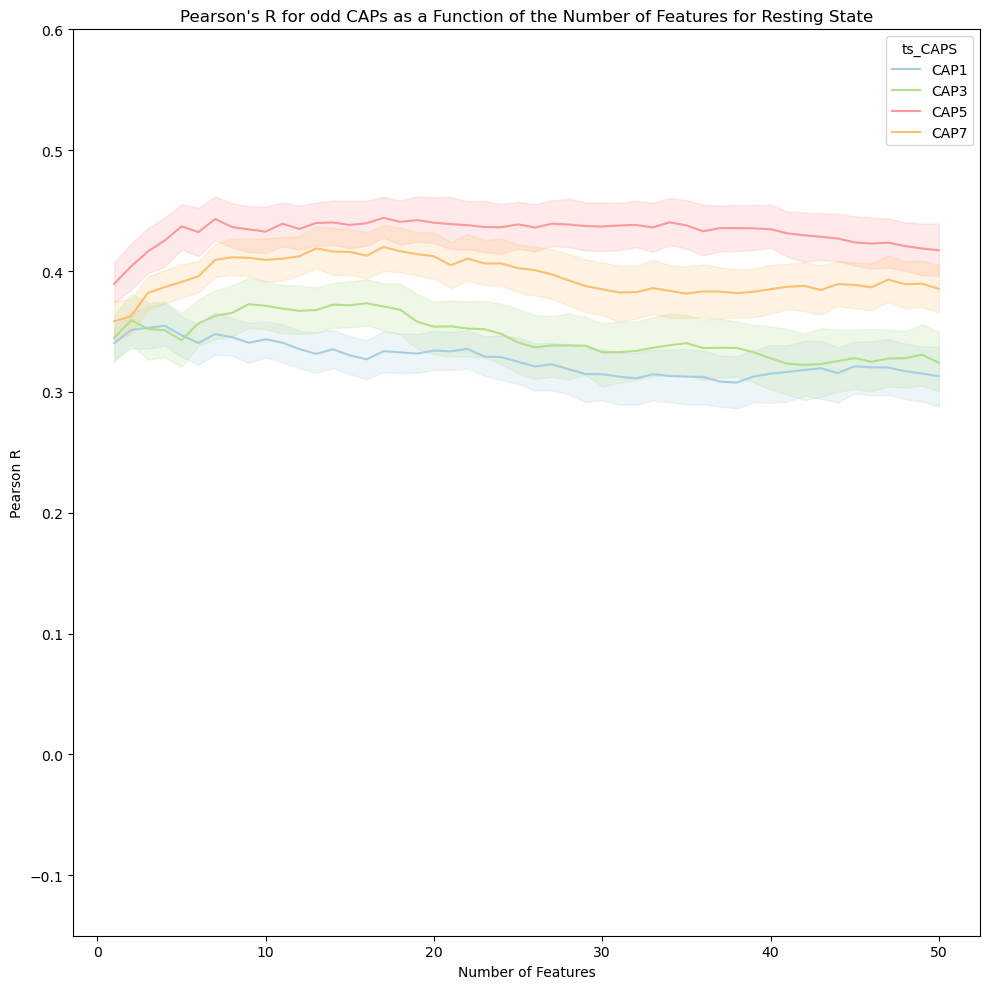

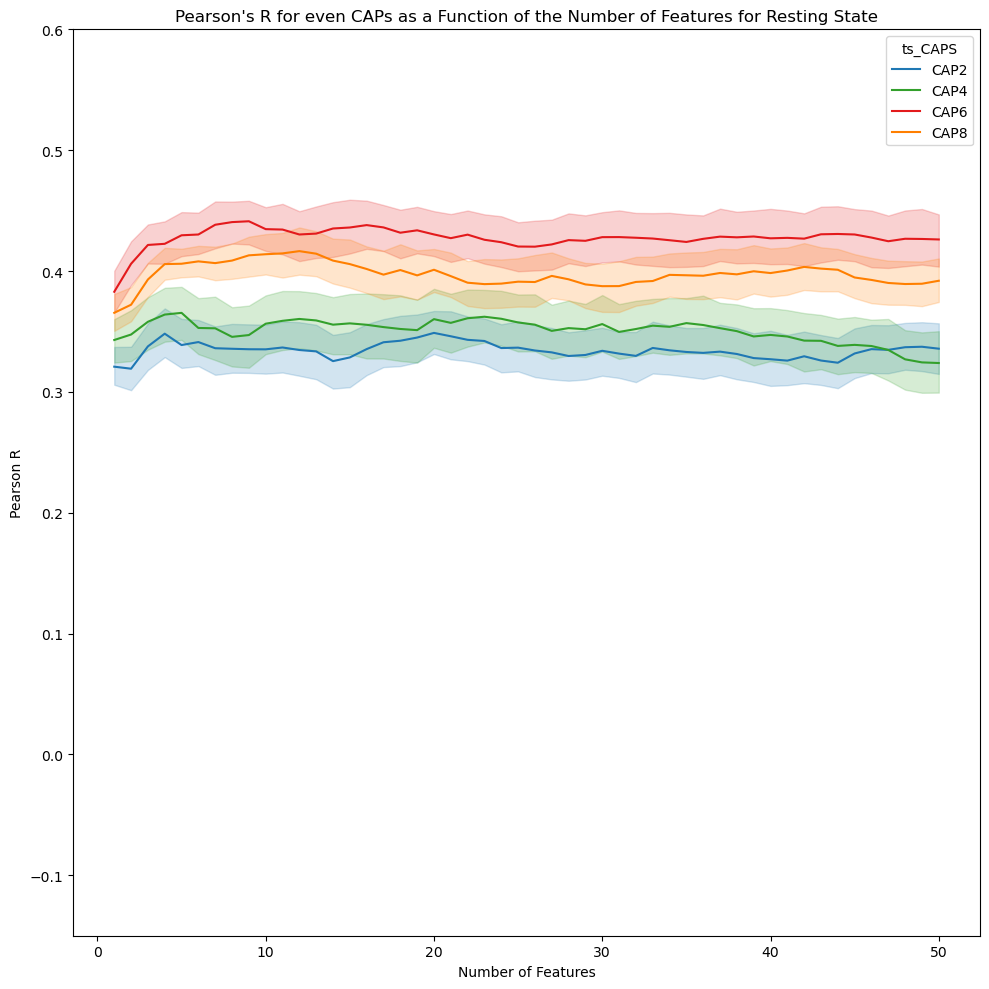

In [14]:
import itertools
directory = Path("/home/slouviot/01_projects/eeg_brain_state_prediction/data/custom_envelope_caps/subject_level_feature_selection")
tasks = ["checker", "rest"]
additional_infos = ["EegOnly", "WithPupil"]
prod = itertools.product(tasks, additional_infos)

group_pd = pd.DataFrame()
for TASK, additional_info in prod:
    for file in directory.iterdir():
        if file.suffix == ".csv":
            description = re.search(r"desc-\w+(?=_)", file.name).group(0)
            task = re.search(r"task-\w+(?=_)", file.name).group(0)
            subject = re.search(r"sub-\w+(?=_)", file.name).group(0)
            condition = (
            description.split("-")[1] == "CustomEnvBk8Caps"+additional_info,
            task.split("-")[1] == f"{TASK}"
            )
            if all(condition):
                df = pd.read_csv(file)
                df["task"] = task.split("-")[1]
                df["description"] = additional_info
                group_pd = pd.concat([group_pd, df.reset_index()])
    plot_screening(group_pd, TASK, "prediction_as_function_nb_features_subject_level", additional_info)


# Subject and Session selection

In [38]:
df1_keys = sub_ses_pd[["subject", "session", "ts_CAPS", "n_features", "task", "description"]].drop_duplicates()
select_sub_pd = sub_pd.merge(df1_keys, how = "right", on = ["subject", "session", "ts_CAPS", "n_features", "task", "description"])
select_group_pd = group_pd.merge(df1_keys, how = "right", on = ["subject", "session", "ts_CAPS", "n_features", "task", "description"])

In [41]:
difference = sub_ses_pd.copy()
difference["pearson_r"] = select_sub_pd["pearson_r"].values - select_group_pd["pearson_r"].values
difference = difference[["subject","session","ts_CAPS","n_features","task","pearson_r", "description"]]

checker EegOnly
checker WithPupil
rest EegOnly
rest WithPupil


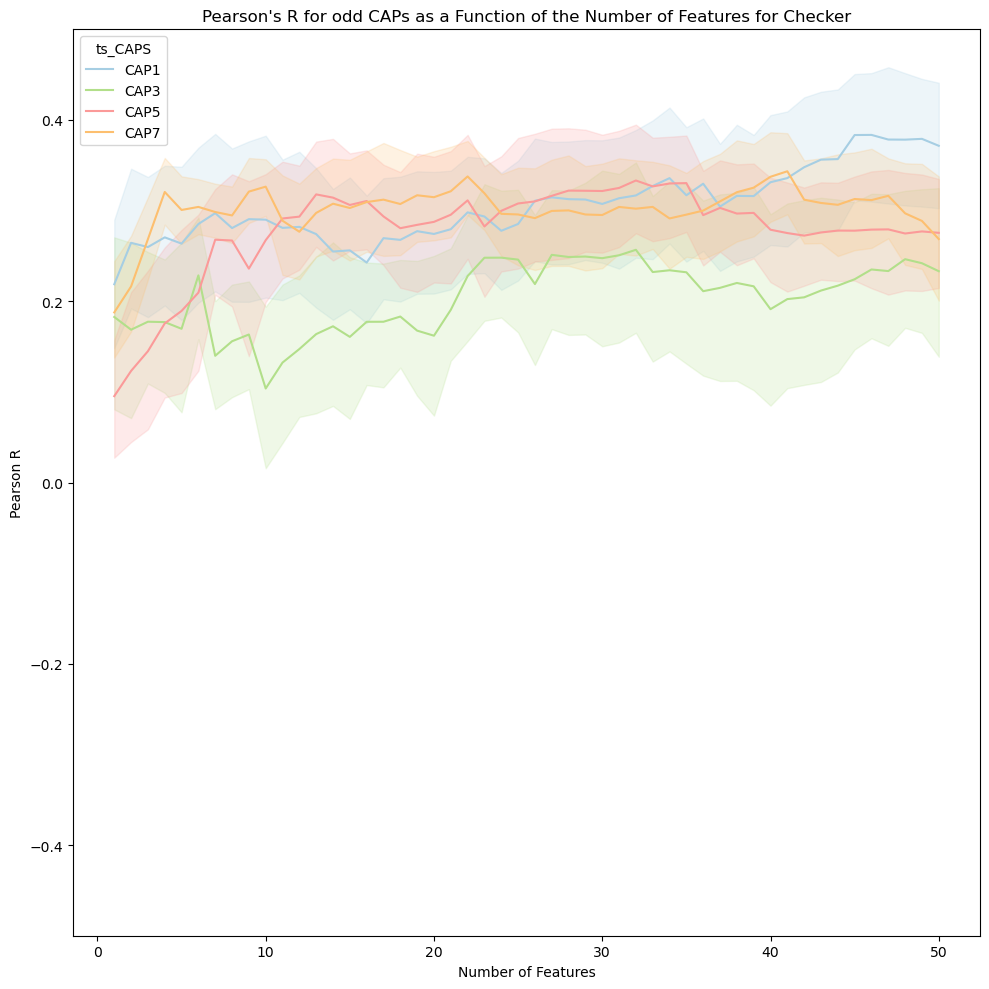

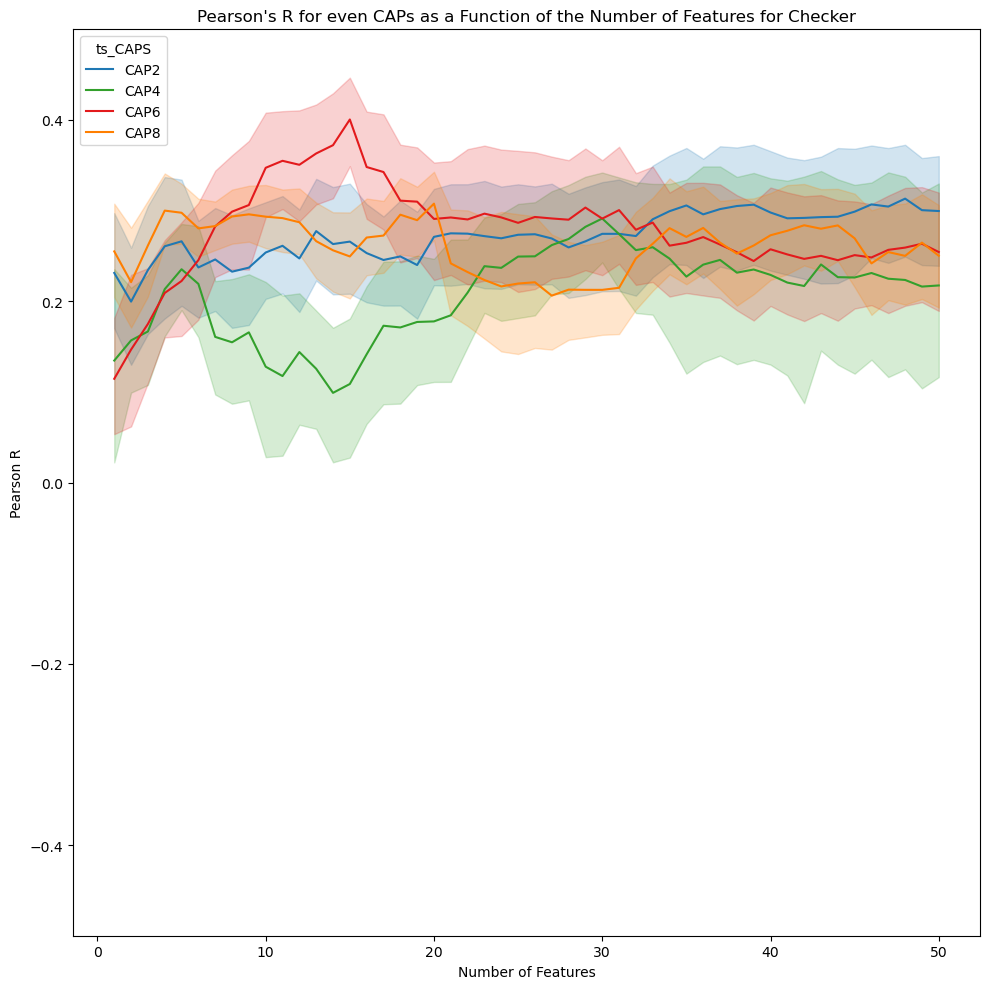

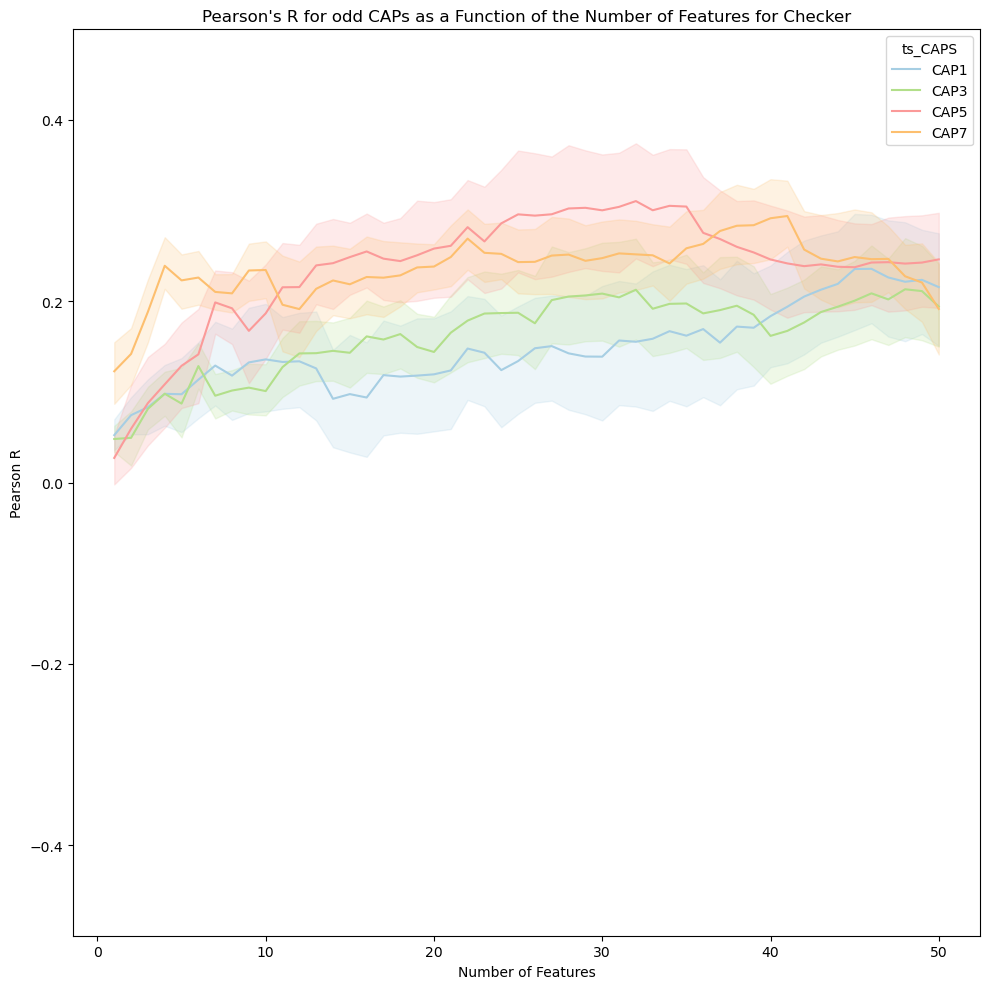

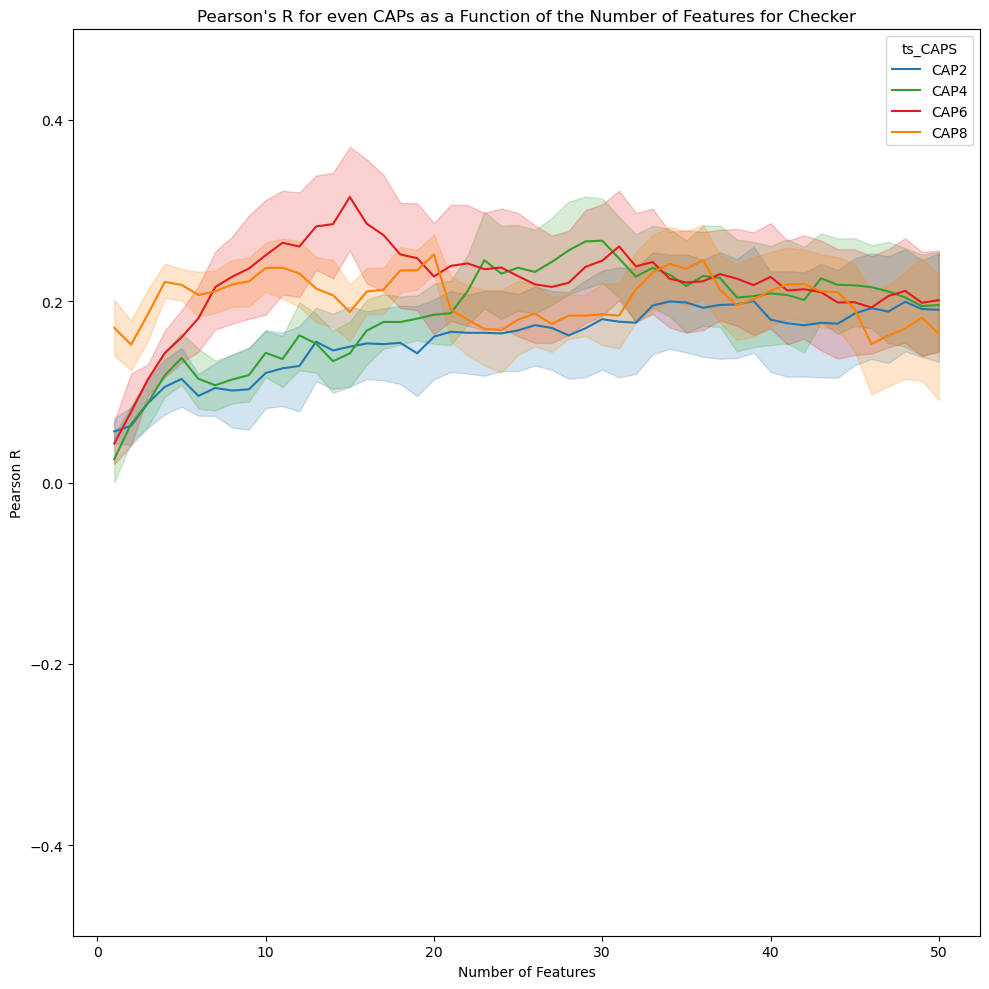

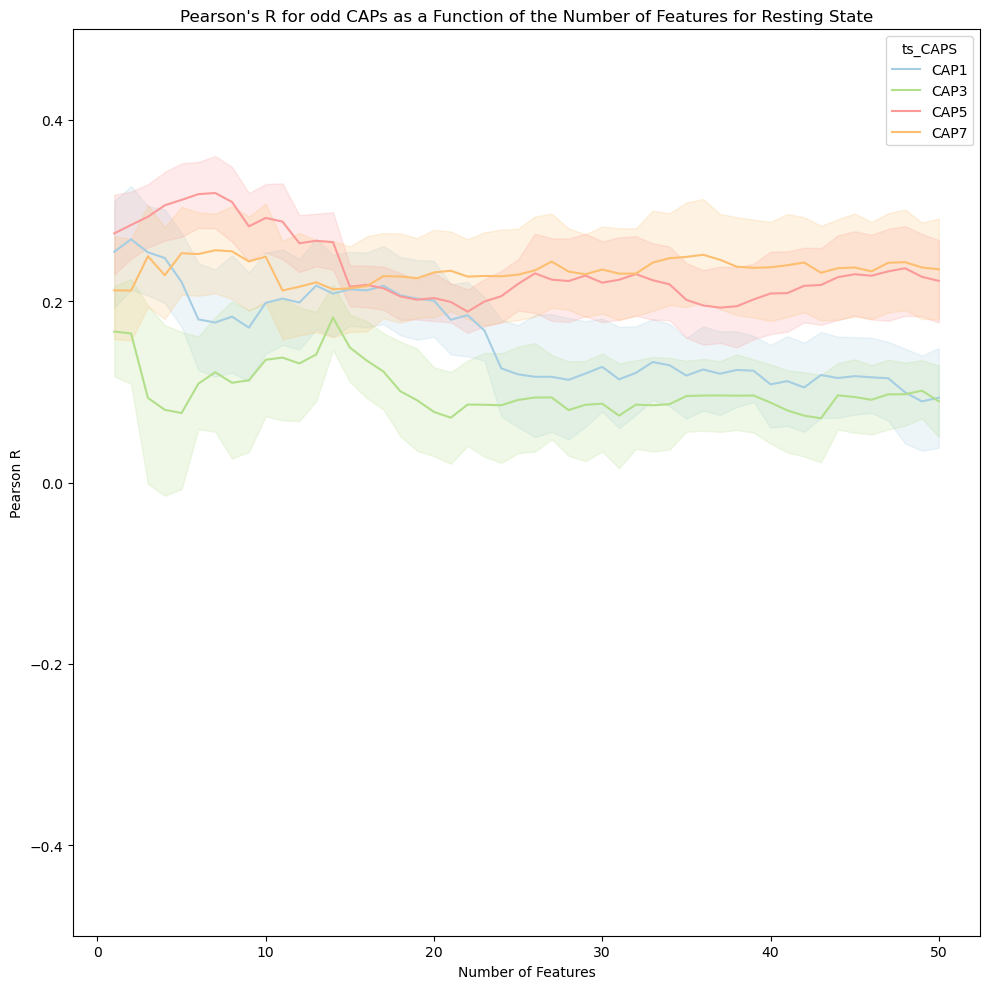

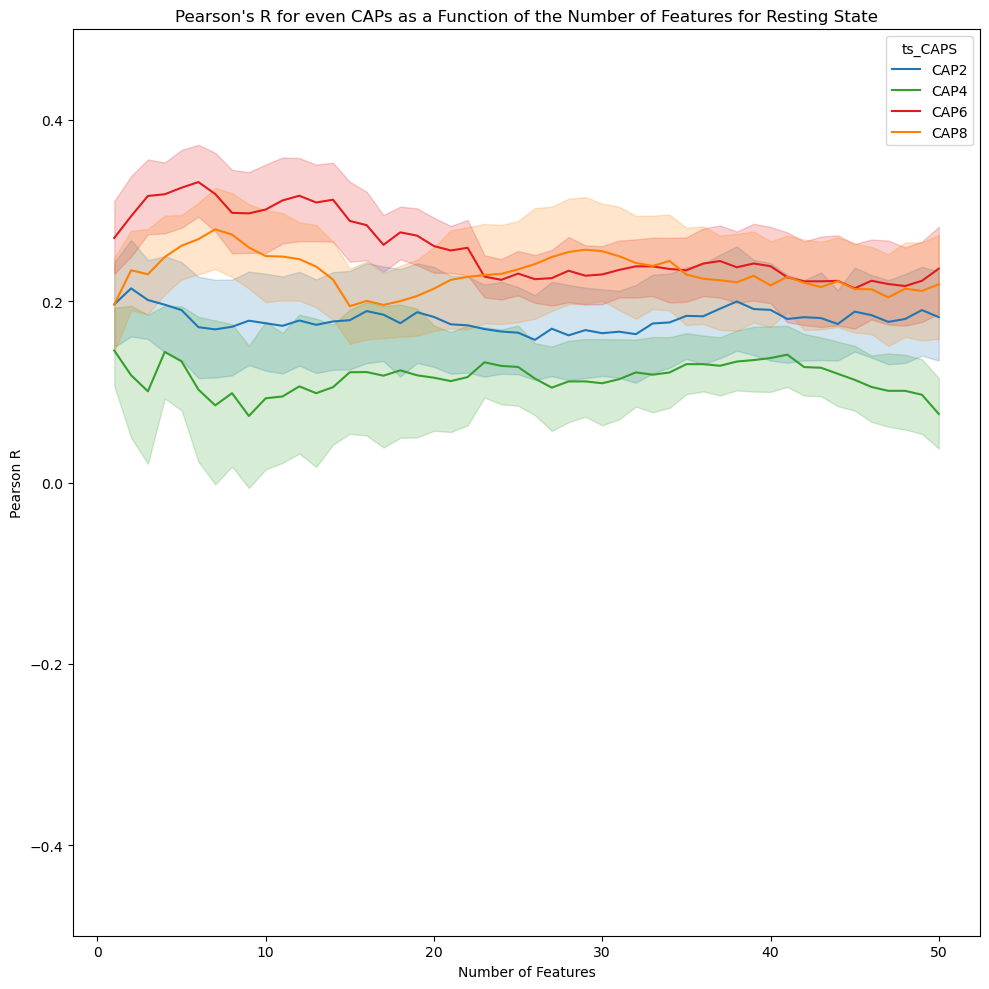

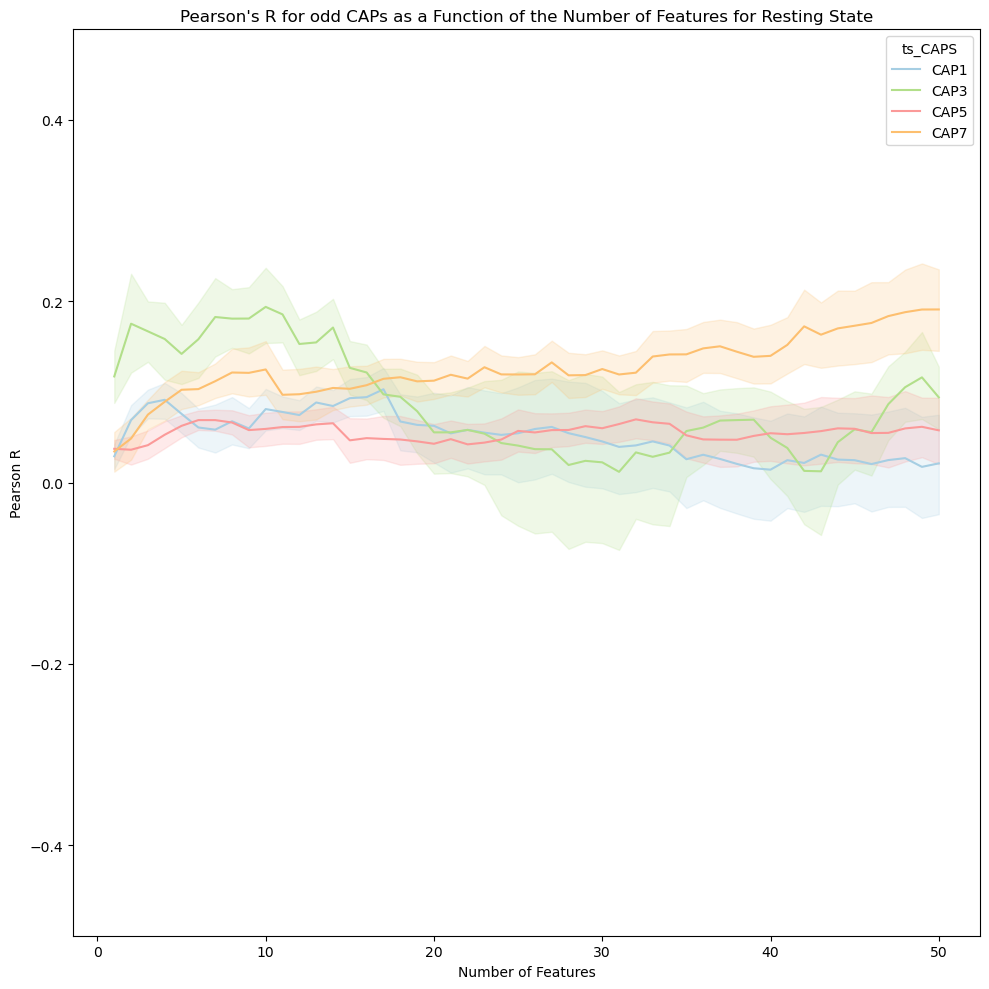

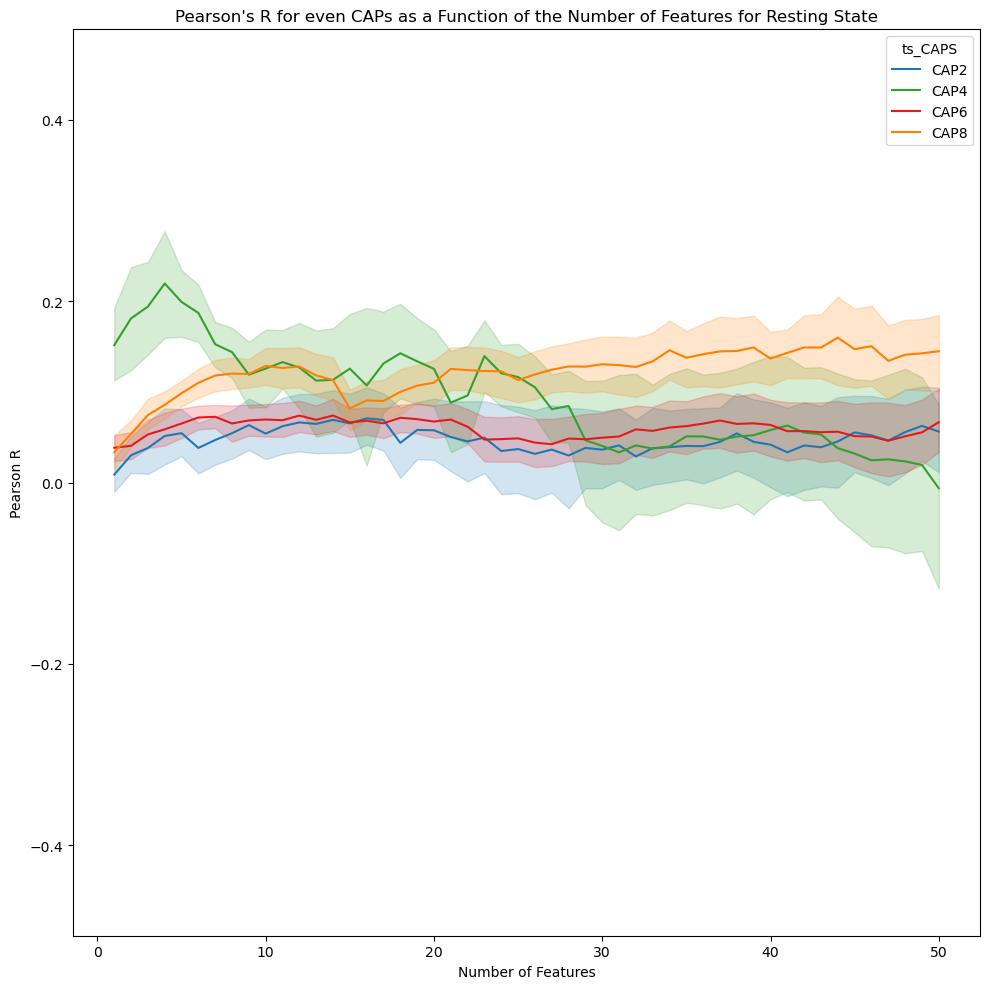

In [42]:
tasks = ["checker", "rest"]
additional_infos = ["EegOnly", "WithPupil"]
prod = itertools.product(tasks, additional_infos)
for TASK, additional_info in prod:
    print(TASK, additional_info)
    plot_screening(
        difference[(difference["task"] == TASK) & (difference["description"] == additional_info)],
        TASK,
        "diff_group_intra-sub_level_feature_selection",
        additional_info
    )

# Strict Selection

In [11]:
import bids_explorer.architecture.architecture as arch
from pathlib import Path
architecture = arch.BidsArchitecture(root = Path("/data2/Projects/eeg_fmri_natview/derivatives"), datatype = "multimodal", task = "rest")

In [ ]:
import numpy as np
import itertools
sessions = ["01","02"]
selected = (
    architecture.database.groupby("subject").session.unique().apply(
        lambda x: list(
            itertools.takewhile(lambda y: y in sessions, x)
        )
    )
)
selected.index[np.where(selected.apply(len) == len(sessions))[0]]

In [ ]:
import numpy as np
def get_subjects_with_two_sessions(architecture: arch.BidsArchitecture) -> list[str]:
    subjects = architecture.database["subject"].unique()
    mask = (architecture.database.groupby("subject").session.nunique() == 2).values.tolist()
    subject_selected = subjects[np.where(mask)[0]]
    return list(subject_selected)

new = architecture.select(subject = get_subjects_with_two_sessions(architecture))

In [ ]:
architecture.select(inplace=True, session = ["01","02"], task = "checker", extension = ".pkl", datatype = "eeg")

BidsArchitecture: 335 files, 0 errors, subjects: 22, sessions: 2, datatypes: 1, tasks: 1

In [ ]:
def strict_select(
    architecture: arch.BidsArchitecture,
    inplace: bool = False,
    **kwargs: str | list[str | None] | None,
) -> arch.BidsArchitecture:
    inputs: dict[str, list[str | None]] = {}
    nb_required = 0
    for key, value in kwargs.items():
        if value is None:
            continue

        if isinstance(value, list):
            inputs[key] = value  # type: ignore
            nb_required += len(value)

        elif isinstance(value, str):
            inputs[key] = [value]  # type: ignore
            nb_required += 1

        else:
            raise ValueError(
                "Invalid input type, expected list or str, got "
                f"{type(value)} instead"
            )

    if nb_required == 0:
        return architecture

    architecture.select(inplace=True, **inputs)  # type: ignore
    architecture.database.drop(
        columns=list(inputs.keys()) + ["root", "filename"],
        inplace=True,
    )

    duplicates = architecture.database.duplicated()

    return architecture
